In [25]:
import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

import Chronocell
from protein_from_RNA import *

In [26]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5_204_fitted_genes"

In [27]:
genes = pd.read_csv(f"data/{prefix}.csv") # Genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

# Genes in X_fwd object
gene_df = genes.iloc[gene_idx]

In [28]:
# Get X_fwd for each gene

# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)

import pickle
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
     states_per_gene = pickle.load(f)

In [29]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [30]:
t = traj.t

In [31]:
# Y = traj.X
Q = traj.Q[:, 0, :] 
# tau = traj.tau # State transition times (global)
t = traj.t
# theta = traj.theta
topo = traj.topo
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

## Get half-life data

In [32]:
data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")
subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)

In [33]:
df_list[0].head()

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts
0,Cul4b,31.378265
1,Dhx8,28.700000
2,Znf335,3.599724
3,Arfgef2,24.371302
4,Cdc27,21.057713


In [34]:
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)


## Subset half-life data to genes of interest

In [35]:
df_subset = df.loc[df['Gene'].isin(gene_df['Gene_symbol'])]

In [36]:
df_subset

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart
1962,Bst2,NaN,8.89,NaN,NaN,NaN,NaN,NaN
2973,Cd63,19.953640,57.49,NaN,NaN,NaN,NaN,NaN
2976,Cd9,NaN,32.19,NaN,NaN,NaN,NaN,NaN
7683,Itgb1,63.400000,11.75,60.0,NaN,28.3,NaN,62.88
8793,Lamp1,NaN,30.18,NaN,NaN,38.7,NaN,35.04
8875,Lgals3,115.005279,60.99,NaN,NaN,44.3,NaN,NaN
12968,Procr,NaN,22.27,NaN,NaN,NaN,NaN,NaN
16288,Sbno1,10.793772,14.04,NaN,NaN,NaN,NaN,NaN
16289,Sbno2,NaN,107.96,NaN,NaN,NaN,NaN,NaN
18975,Vcam1,12.751839,18.18,NaN,NaN,15.5,NaN,NaN


## Get order of genes in half-life data

In [37]:
genes = df_subset['Gene'].tolist()

gene_df = gene_df.set_index("Gene_symbol", drop=False)
 
# Get row order so X_bw will be indexed in the same order as rows of halflife
gene_order_idx = gene_df.index.get_indexer(genes)

## Convert half-life to degradation rate

In [38]:
half_life_cols = [col for col in df_subset.columns if "Half-life" in col]
df_deg = np.log(2)/df_subset[half_life_cols]

# Match order to order of genes in 
median_deg = np.nanmedian(df_deg, axis=1)

In [39]:
df_subset['Gene']

1962       Bst2
2973       Cd63
2976        Cd9
7683      Itgb1
8793      Lamp1
8875     Lgals3
12968     Procr
16288     Sbno1
16289     Sbno2
18975     Vcam1
Name: Gene, dtype: object

## Impute protein

In [40]:
# n_genes = df_subset.shape[0]
# n_cells = Q.shape[0]

# P = np.full((n_cells, n_genes), -1)

t_l = np.repeat(0, len(t))

P_array = np.empty((len(t), len(gene_order_idx)))

for idx, value in enumerate(gene_order_idx):
    # print(gene_df.iloc[value])
    # print(df_subset['Gene'].iloc[idx]) 
    
    phi = np.zeros((1, 2))
    phi[:,0] = 20 
    phi[:,-1] = median_deg[idx]
    
    X_fwd = X_fwd_per_gene[value]
    states = np.asarray(states_per_gene[value])
    
    # Get most probable state for spliced RNA at each time point
    Y = states[X_fwd.argmax(axis=0)]
    Y = Y[:, None, :]
    
    P_observed, P = simulate_protein_from_RNA(Y, topo, t, t_l, phi, random_seed=0)
    
    P_array[:, idx] = P.flatten()

In [41]:
sampleinfo = pd.read_csv(f"data/{prefix}_sampleinfo_barcode_level.csv")
orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [42]:
gene_idx = 1
gene = df_subset['Gene'].iloc[gene_idx]

t_index_per_cell = Q.argmax(axis=1)

expr_protein = pd.DataFrame(
    P_array[:, gene_idx][t_index_per_cell], 
    index=sampleinfo['Cell_ID'], 
    columns=[gene]
)
prot = orig_corr.loc[orig_corr['Gene'].isin([gene]), 'Protein']

In [43]:
expr_RNA = expr_RNA.loc[expr_protein.index]
expr_ADT = expr_ADT.loc[expr_protein.index]

In [44]:
Q_max_idx = np.argmax(Q, axis=1)
t_per_cell = t[np.sort(Q_max_idx)]

cell_order_idx = np.argsort(Q_max_idx)
cell_index = expr_ADT.index[cell_order_idx]

expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]
expr_protein_ordered = expr_protein.loc[cell_index]

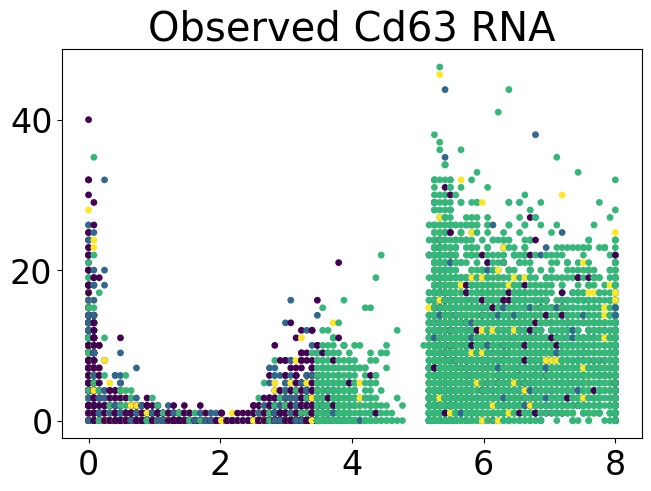

In [45]:
plt.scatter(
    t_per_cell,
    expr_RNA_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} RNA");

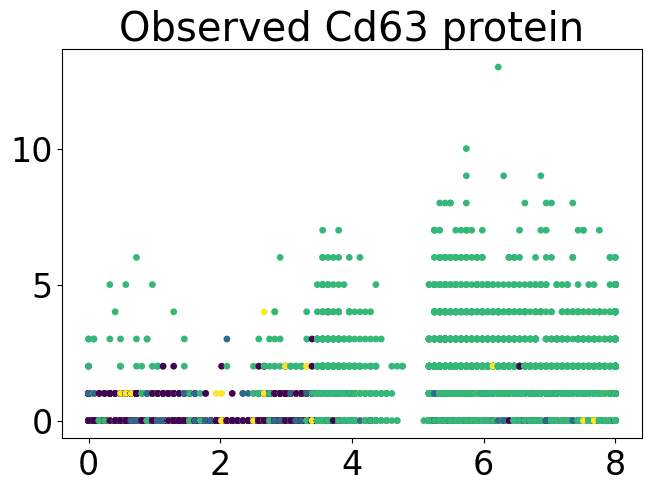

In [46]:
plt.scatter(
    t_per_cell,
    expr_ADT[prot],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} protein");

Text(0.5, 1.0, 'Imputed Cd63 protein at each time point')

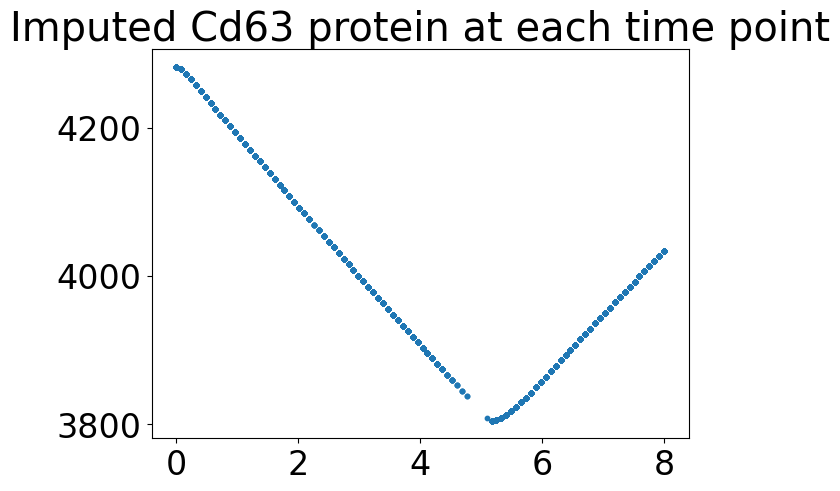

In [47]:
plt.scatter(t_per_cell, expr_protein_ordered, s=10)
plt.title(f"Imputed {gene} protein at each time point")

In [ ]:
orig_corr_subset = orig_corr.loc[orig_corr['Gene'].isin(expr_protein.columns)]
expr_ADT_subset = expr_ADT.loc[:, orig_corr_subset['Protein']]

In [294]:
expr_protein.columns = expr_ADT_subset.columns

In [295]:
expr_protein

,CD317
Cell_ID,
AAAGGGCTCTGAGCAT-6,201.533818
AAACCCAAGGGAGTTC-6,197.759223
AAAGGATTCACCCTCA-6,206.548704
AAAGGTATCTCTCGAC-6,206.939594
AAACGAACAACAAAGT-6,197.385674
...,...
TTTGGAGGTCTCACGG-2,209.300519
TTTGGAGTCGACGTCG-2,191.456623
TTTGGAGCACAAGTTC-2,190.392902


In [296]:
expr_ADT_subset.corrwith(expr_protein)

CD317   -0.014796
dtype: float64

In [292]:
expr_ADT_subset

,CD317
Cell_ID,
AAAGGGCTCTGAGCAT-6,1
AAACCCAAGGGAGTTC-6,0
AAAGGATTCACCCTCA-6,0
AAAGGTATCTCTCGAC-6,0
AAACGAACAACAAAGT-6,0
...,...
TTTGGAGGTCTCACGG-2,0
TTTGGAGTCGACGTCG-2,0
TTTGGAGCACAAGTTC-2,0
